In [3]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch


In [4]:
pip install --upgrade "jax[cpu]"


   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 3.1/3.1 MB 22.7 MB/s  0:00:00
   ---------------------------------------- 0.0/62.8 MB ? eta -:--:--
   --- ------------------------------------ 6.0/62.8 MB 28.8 MB/s eta 0:00:02
   -------- ------------------------------- 12.6/62.8 MB 29.7 MB/s eta 0:00:02
   ------------ --------------------------- 18.9/62.8 MB 29.7 MB/s eta 0:00:02
   ---------------- ----------------------- 25.7/62.8 MB 30.0 MB/s eta 0:00:02
   -------------------- ------------------- 32.0/62.8 MB 30.1 MB/s eta 0:00:02
   ------------------------ --------------- 38.5/62.8 MB 30.3 MB/s eta 0:00:01
   ---------------------------- ----------- 45.4/62.8 MB 30.4 MB/s eta 0:00:01
   ------------------------------- -------- 49.8/62.8 MB 29.1 MB/s eta 0:00:01
   ------------------------------------ --- 56.6/62.8 MB 29.6 MB/s eta 0:00:01
   ---------------------------------------  62.7/62.8 MB 29.8 MB/s eta 0:00:0

Matplotlib is building the font cache; this may take a moment.


Epoch 0, Loss = 2.388e+02
Epoch 100, Loss = 2.043e-01
Epoch 200, Loss = 1.189e-01
Epoch 300, Loss = 8.938e-02
Epoch 400, Loss = 7.082e-02
Epoch 500, Loss = 5.759e-02
Epoch 600, Loss = 4.784e-02
Epoch 700, Loss = 4.048e-02
Epoch 800, Loss = 3.480e-02
Epoch 900, Loss = 3.031e-02
Epoch 1000, Loss = 2.668e-02
Epoch 1100, Loss = 2.371e-02
Epoch 1200, Loss = 2.122e-02
Epoch 1300, Loss = 1.911e-02
Epoch 1400, Loss = 1.732e-02
Epoch 1500, Loss = 1.577e-02
Epoch 1600, Loss = 1.442e-02
Epoch 1700, Loss = 1.325e-02
Epoch 1800, Loss = 1.221e-02
Epoch 1900, Loss = 1.131e-02


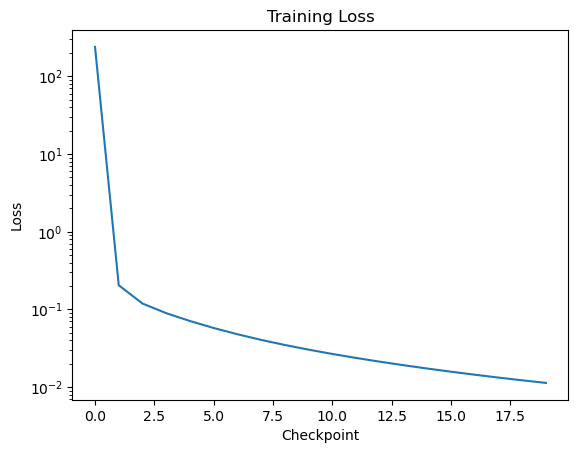

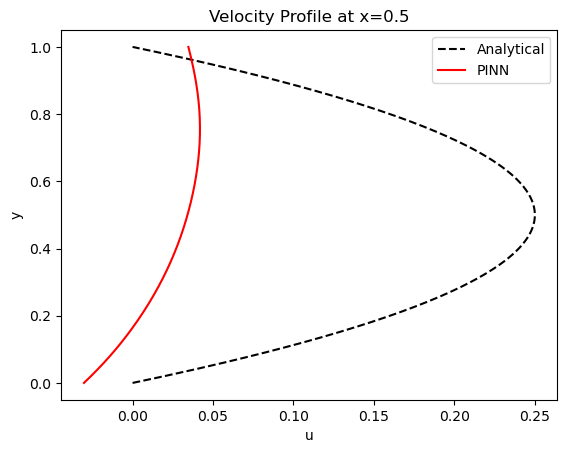

In [5]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax import grad, vmap, jit, random

# ---------------------------------------------------------
# 1. Neural network definition (MLP)
# ---------------------------------------------------------

def init_mlp(layer_sizes, key):
    params = []
    keys = random.split(key, len(layer_sizes))
    for m, n, k in zip(layer_sizes[:-1], layer_sizes[1:], keys):
        W = random.normal(k, (m, n)) * jnp.sqrt(2.0 / m)
        b = jnp.zeros(n)
        params.append((W, b))
    return params

def mlp_forward(params, x):
    for W, b in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W, b = params[-1]
    return x @ W + b  # final layer (u, v, p)

# ---------------------------------------------------------
# 2. PINN model wrapper
# ---------------------------------------------------------

def model(params, x, y):
    inp = jnp.stack([x, y], axis=-1)
    out = mlp_forward(params, inp)
    u, v, p = out[..., 0], out[..., 1], out[..., 2]
    return u, v, p

# ---------------------------------------------------------
# 3. PDE residuals (Navier–Stokes)
# ---------------------------------------------------------

Re = 1.0
G = 2.0  # body force

def pde_residual(params, x, y):
    u, v, p = model(params, x, y)

    # First derivatives
    u_x = grad(lambda x_: model(params, x_, y)[0])(x)
    u_y = grad(lambda y_: model(params, x, y_)[0])(y)

    v_x = grad(lambda x_: model(params, x_, y)[1])(x)
    v_y = grad(lambda y_: model(params, x, y_)[1])(y)

    p_x = grad(lambda x_: model(params, x_, y)[2])(x)
    p_y = grad(lambda y_: model(params, x, y_)[2])(y)

    # Second derivatives
    u_xx = grad(lambda x_: grad(lambda x__: model(params, x__, y)[0])(x_))(x)
    u_yy = grad(lambda y_: grad(lambda y__: model(params, x, y__)[0])(y_))(y)

    v_xx = grad(lambda x_: grad(lambda x__: model(params, x__, y)[1])(x_))(x)
    v_yy = grad(lambda y_: grad(lambda y__: model(params, x, y__)[1])(y_))(y)

    # PDE residuals
    r_c = u_x + v_y
    r_mx = u * u_x + v * u_y + p_x - (1/Re)*(u_xx + u_yy) - G
    r_my = u * v_x + v * v_y + p_y - (1/Re)*(v_xx + v_yy)

    return r_c, r_mx, r_my

# Vectorize PDE residuals
pde_residual_v = vmap(pde_residual, in_axes=(None, 0, 0))

# ---------------------------------------------------------
# 4. Loss function
# ---------------------------------------------------------

def loss_fn(params, X_int, Y_int, X_wall, Y_wall):
    # PDE loss
    r_c, r_mx, r_my = pde_residual_v(params, X_int, Y_int)
    loss_pde = jnp.mean(r_c**2 + r_mx**2 + r_my**2)

    # Wall BCs: u=0, v=0 at y=0,1
    u_w, v_w, _ = model(params, X_wall, Y_wall)
    loss_bc = jnp.mean(u_w**2 + v_w**2)

    return loss_pde + loss_bc

loss_grad = jit(grad(loss_fn))

# ---------------------------------------------------------
# 5. Training
# ---------------------------------------------------------

key = random.PRNGKey(0)
params = init_mlp([2, 64, 64, 64, 64, 3], key)

# Sample points
N_int = 2000
N_wall = 400

X_int = np.random.rand(N_int)
Y_int = np.random.rand(N_int)

X_wall = np.random.rand(N_wall)
Y_wall = np.concatenate([np.zeros(N_wall//2), np.ones(N_wall//2)])

X_int = jnp.array(X_int)
Y_int = jnp.array(Y_int)
X_wall = jnp.array(X_wall)
Y_wall = jnp.array(Y_wall)

# Optimizer
lr = 1e-3
loss_history = []

for epoch in range(2000):
    grads = loss_grad(params, X_int, Y_int, X_wall, Y_wall)
    params = [(W - lr*dW, b - lr*db) for (W,b), (dW,db) in zip(params, grads)]

    if epoch % 100 == 0:
        L = loss_fn(params, X_int, Y_int, X_wall, Y_wall)
        loss_history.append(L)
        print(f"Epoch {epoch}, Loss = {L:.3e}")

# ---------------------------------------------------------
# 6. Visualization
# ---------------------------------------------------------

plt.plot(loss_history)
plt.yscale("log")
plt.title("Training Loss")
plt.xlabel("Checkpoint")
plt.ylabel("Loss")
plt.show()

# Compare predicted vs analytical u(y)
y_plot = jnp.linspace(0,1,200)
x_mid = jnp.ones_like(y_plot)*0.5

u_pred, _, _ = model(params, x_mid, y_plot)
u_exact = y_plot*(1-y_plot)

plt.plot(u_exact, y_plot, 'k--', label="Analytical")
plt.plot(u_pred, y_plot, 'r-', label="PINN")
plt.xlabel("u")
plt.ylabel("y")
plt.legend()
plt.title("Velocity Profile at x=0.5")
plt.show()
